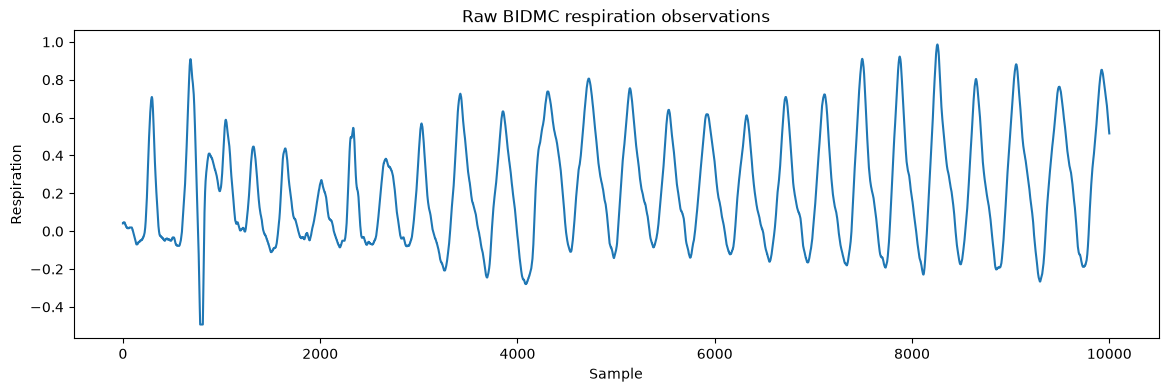

In [1]:
import featuregraph_research as fg
import matplotlib.pyplot as plt

bidmc = fg.datasets.bidmc(subject=10)

bidmc.loc[:10000].plot(
    y="respiration",
    figsize=(14, 4),
    legend=False,
    title="Raw BIDMC respiration observations",
)

plt.ylabel("Respiration")
plt.xlabel("Sample")
plt.show()

In [2]:
respiration = fg.oscillation.Oscillation(
    signals="respiration",
    group="subject",
    smooth_signal=False,
)

respiration_features = respiration.fit_transform(
    bidmc
)

respiration_objects = respiration.summarize(
    respiration_features,
    signal="respiration",
)

In [3]:
respiration_objects.table.head()

,subject,oscillation_id,is_complete,start_index,peak_index,end_index,rise_duration,fall_duration,duration,period,amplitude,rising_mean_rate,falling_mean_rate,peak_rise_rate,peak_fall_rate,temporal_symmetry
0,10,1,True,9.0,16.0,61.0,7.0,45.0,52.0,NaN,0.015534,0.004438,0.000690,0.000582,0.001359,0.269231
1,10,2,True,61.0,74.0,146.0,13.0,72.0,85.0,58.0,0.044660,0.006871,0.001241,0.000388,0.002524,0.305882
2,10,3,True,146.0,297.0,428.0,151.0,131.0,282.0,223.0,0.388351,0.005144,0.005929,0.015729,0.014952,0.929078
3,10,4,True,428.0,450.0,465.0,22.0,15.0,37.0,153.0,0.003883,0.000353,0.000518,0.000971,0.000582,0.810811
4,10,5,True,465.0,470.0,491.0,5.0,21.0,26.0,20.0,0.003884,0.001553,0.000370,0.000194,0.000583,0.384615


In [4]:
wave = respiration_objects.table.iloc[10]

start = int(wave["start_index"])
peak = int(wave["peak_index"])
end = int(wave["end_index"])

segment = bidmc.loc[start:end]

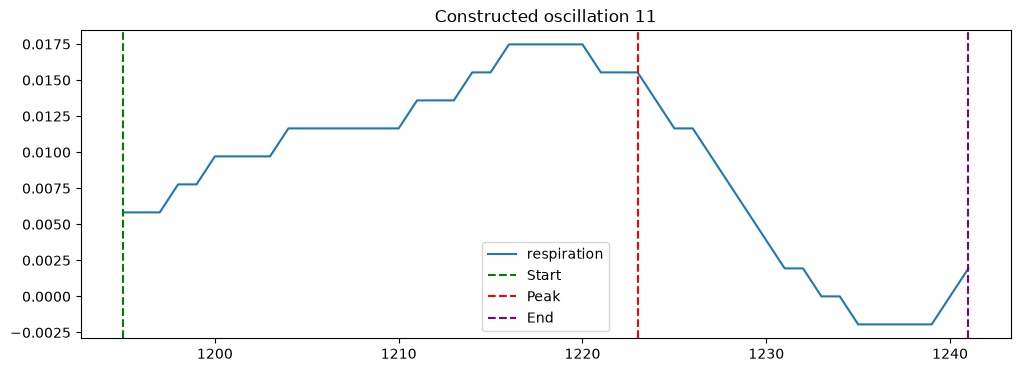

In [5]:
ax = segment.plot(
    y="respiration",
    figsize=(12, 4),
    legend=False,
    title=f"Constructed oscillation {wave['oscillation_id']}",
)

ax.axvline(
    start,
    color="green",
    linestyle="--",
    label="Start",
)

ax.axvline(
    peak,
    color="red",
    linestyle="--",
    label="Peak",
)

ax.axvline(
    end,
    color="purple",
    linestyle="--",
    label="End",
)

ax.legend()
plt.show()

In [6]:
wave[
    [
        "oscillation_id",
        "start_index",
        "peak_index",
        "end_index",
        "duration",
        "period",
        "amplitude",
        "temporal_symmetry",
    ]
]

oscillation_id             11
start_index            1195.0
peak_index             1223.0
end_index              1241.0
duration                 46.0
period                   58.0
amplitude            0.009709
temporal_symmetry    0.782609
Name: 10, dtype: object

In [7]:
long_oscillations = (
    respiration_objects
    .query()
    .where(duration__ge=100)
    .select(
        "oscillation_id",
        "start_index",
        "end_index",
        "duration",
        "amplitude",
    )
    .collect()
)

In [8]:
long_count = len(long_oscillations)
total_count = respiration_objects.count
percentage = 100 * long_count / total_count

{
    "long_oscillations": long_count,
    "total_oscillations": total_count,
    "percentage": percentage,
}

{'long_oscillations': 169,
 'total_oscillations': 264,
 'percentage': 64.01515151515152}

In [9]:
slow_symmetric_oscillations = (
    respiration_objects
    .query()
    .where(
        duration__ge=100,
        temporal_symmetry__ge=0.9,
    )
    .select(
        "oscillation_id",
        "duration",
        "amplitude",
        "temporal_symmetry",
    )
    .order_by(
        "amplitude",
        ascending=False,
    )
    .collect()
)

slow_symmetric_oscillations

,oscillation_id,duration,amplitude,temporal_symmetry
0,171,189.0,0.814560,0.984127
1,7,239.0,0.700970,0.987448
2,61,416.0,0.557280,0.923077
3,29,455.0,0.506795,0.975824
4,69,359.0,0.497085,0.947075
5,50,298.0,0.486405,0.979866
6,73,376.0,0.459220,0.920213
7,81,282.0,0.426215,0.950355
8,52,348.0,0.422330,0.988506
9,176,277.0,0.417475,0.931408


In [10]:
accumulation = fg.accumulation.Accumulation(
    signals="respiration",
    group="subject",
)

accumulation_features = accumulation.fit_transform(
    respiration_features
)

accumulation_objects = accumulation.summarize(
    accumulation_features,
    signal="respiration",
)

In [11]:
high_accumulation = (
    accumulation_objects
    .query()
    .where(total_auc__gt=50)
    .select(
        "accumulation_id",
        # "parent_oscillation_id",
        "total_auc",
        "accumulation_rate",
        "centroid_time",
    )
    .order_by(
        "total_auc",
        ascending=False,
    )
    .collect()
)

high_accumulation

,accumulation_id,total_auc,accumulation_rate,centroid_time
0,249,297.182863,0.803197,189.771977
1,57,262.373998,0.676222,182.868341
2,197,252.702853,0.552960,223.710086
3,29,252.620228,0.555209,237.107914
4,80,237.773349,0.640899,165.540983
...,...,...,...,...
143,205,62.780476,0.286669,143.167668
144,242,62.600000,0.224373,86.647812
145,143,56.533793,0.210947,82.119158
146,16,52.384459,0.171191,127.278855


In [12]:
eastman = fg.datasets.eastman(
    fault_number=1,
    simulation_run=1,
)

temperature = fg.oscillation.Oscillation(
    signals="reactor_temperature",
    group=[
        "fault_number",
        "simulation_run",
    ],
    smooth_signal=True,
    smooth_window=20,
)

temperature_features = temperature.fit_transform(
    eastman
)

temperature_objects = temperature.summarize(
    temperature_features,
    signal="reactor_temperature",
)

In [13]:
{
    "respiration": respiration_objects.properties,
    "reactor_temperature": temperature_objects.properties,
}

{'respiration': ('oscillation_id',
  'is_complete',
  'start_index',
  'peak_index',
  'end_index',
  'rise_duration',
  'fall_duration',
  'duration',
  'period',
  'amplitude',
  'rising_mean_rate',
  'falling_mean_rate',
  'peak_rise_rate',
  'peak_fall_rate',
  'temporal_symmetry'),
 'reactor_temperature': ('oscillation_id',
  'is_complete',
  'start_index',
  'peak_index',
  'end_index',
  'rise_duration',
  'fall_duration',
  'duration',
  'period',
  'amplitude',
  'rising_mean_rate',
  'falling_mean_rate',
  'peak_rise_rate',
  'peak_fall_rate',
  'temporal_symmetry')}